<a href="https://colab.research.google.com/github/sivaspiker-wayne/demo_project/blob/main/churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("/content/churn_prediction.csv")

In [4]:
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,days_since_last_transaction,...,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
0,1,3135,66,0,0.0,0,187.0,2,755,224.0,...,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0
1,6,2531,42,0,2.0,0,1494.0,3,388,58.0,...,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1
2,7,263,42,1,0.0,0,1096.0,2,1666,60.0,...,16059.34,15211.29,13798.82,0.36,0.36,857.50,286.07,15719.44,15349.75,0
3,8,5922,72,0,0.0,1,1020.0,1,1,98.0,...,7714.19,7859.74,11232.37,0.64,0.64,1299.64,439.26,7076.06,7755.98,0
4,9,1145,46,0,0.0,0,623.0,2,317,172.0,...,8519.53,6511.82,16314.17,0.27,0.27,443.13,5688.44,8563.84,5317.04,0


In [5]:
df.shape

(22067, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22067 entries, 0 to 22066
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     22067 non-null  int64  
 1   vintage                         22067 non-null  int64  
 2   age                             22067 non-null  int64  
 3   gender                          22067 non-null  int64  
 4   dependents                      22067 non-null  float64
 5   occupation                      22067 non-null  int64  
 6   city                            22067 non-null  float64
 7   customer_nw_category            22067 non-null  int64  
 8   branch_code                     22067 non-null  int64  
 9   days_since_last_transaction     22067 non-null  float64
 10  current_balance                 22067 non-null  float64
 11  previous_month_end_balance      22067 non-null  float64
 12  average_monthly_balance_prevQ   

In [7]:
df.describe()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,days_since_last_transaction,...,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,...,2.206700e+04,2.206700e+04,22067.000000,2.206700e+04,2.206700e+04,2.206700e+04,2.206700e+04,2.206700e+04,2.206700e+04,22067.000000
mean,15115.161372,2547.069334,47.931345,0.391807,0.377487,0.772420,800.318575,2.211991,874.440975,66.934790,...,7.222013e+03,7.181977e+03,6694.966494,3.943065e+03,3.781366e+03,4.070565e+03,3.720333e+03,7.165418e+03,7.182148e+03,0.193683
std,8737.384035,1598.675520,16.393352,0.488165,1.044629,1.033849,431.454448,0.669556,904.244526,84.133427,...,2.105071e+04,1.927121e+04,17101.802052,8.661750e+04,3.254151e+04,5.726446e+04,2.517514e+04,1.959007e+04,2.097682e+04,0.395192
min,1.000000,180.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,-3.145380e+03,1.428690e+03,-16506.100000,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000
25%,7522.500000,1321.000000,36.000000,0.000000,0.000000,0.000000,409.000000,2.000000,159.000000,11.000000,...,1.906485e+03,2.209835e+03,1817.980000,3.600000e-01,3.700000e-01,4.700000e-01,4.900000e-01,2.029970e+03,2.090665e+03,0.000000
50%,15120.000000,2202.000000,46.000000,0.000000,0.000000,0.000000,848.000000,2.000000,531.000000,28.000000,...,3.426740e+03,3.592880e+03,3380.690000,1.130000e+00,6.440000e+00,2.147300e+02,2.285000e+02,3.501740e+03,3.508160e+03,0.000000
75%,22685.500000,3370.000000,60.000000,1.000000,0.000000,2.000000,1096.000000,3.000000,1374.000000,90.000000,...,6.826095e+03,6.819235e+03,6628.750000,9.937800e+02,1.129115e+03,1.579220e+03,1.643175e+03,6.858385e+03,6.779355e+03,0.000000
max,30301.000000,11353.000000,90.000000,1.000000,52.000000,4.000000,1649.000000,3.000000,4782.000000,365.000000,...,1.001124e+06,1.192704e+06,856596.510000,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,1.074625e+06,1.326487e+06,1.000000


In [8]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
22062,False
22063,False
22064,False
22065,False


In [9]:
df.isnull().sum()

,0
customer_id,0
vintage,0
age,0
gender,0
dependents,0
occupation,0
city,0
customer_nw_category,0
branch_code,0
days_since_last_transaction,0


In [10]:
df.columns

Index(['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation',
       'city', 'customer_nw_category', 'branch_code',
       'days_since_last_transaction', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance', 'churn'],
      dtype='object')

In [11]:
from sklearn.preprocessing import MinMaxScaler
mn = MinMaxScaler()
mn

MinMaxScaler()

In [14]:
x = df.drop(["churn"],axis = 1)
y = df["churn"]
x

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,days_since_last_transaction,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance
0,1,3135,66,0,0.0,0,187.0,2,755,224.0,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71
1,6,2531,42,0,2.0,0,1494.0,3,388,58.0,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16
2,7,263,42,1,0.0,0,1096.0,2,1666,60.0,15202.20,16059.34,15211.29,13798.82,0.36,0.36,857.50,286.07,15719.44,15349.75
3,8,5922,72,0,0.0,1,1020.0,1,1,98.0,7006.93,7714.19,7859.74,11232.37,0.64,0.64,1299.64,439.26,7076.06,7755.98
4,9,1145,46,0,0.0,0,623.0,2,317,172.0,10096.58,8519.53,6511.82,16314.17,0.27,0.27,443.13,5688.44,8563.84,5317.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22062,30295,2041,42,0,0.0,0,146.0,2,286,57.0,7493.69,6777.41,8082.48,3515.03,0.51,90.10,1103.20,1183.04,7956.03,7431.36
22063,30297,1845,10,1,0.0,3,1020.0,2,1207,70.0,1076.43,1076.43,2282.19,2787.70,0.30,0.30,0.30,0.30,1076.43,1076.43
22064,30298,4919,34,1,0.0,0,1046.0,2,223,14.0,3844.10,4069.21,3668.83,3865.55,1.71,2.29,901.00,1014.07,3738.54,3690.32
22065,30299,297,47,0,0.0,2,1096.0,2,588,0.0,65511.97,61017.55,53444.81,21925.81,4666.84,3883.06,168.23,71.80,61078.50,57564.24


In [15]:
from sklearn.preprocessing import MinMaxScaler
mn = MinMaxScaler()
mn

MinMaxScaler()

In [16]:
x = mn.fit_transform(x)
x

array([[0.00000000e+00, 2.64476864e-01, 7.30337079e-01, ...,
        1.34354612e-07, 4.48320528e-03, 4.97922681e-03],
       [1.65016502e-04, 2.10417972e-01, 4.60674157e-01, ...,
        1.08760059e-03, 4.20346471e-03, 5.14327036e-03],
       [1.98019802e-04, 7.42862257e-03, 4.60674157e-01, ...,
        2.02281476e-04, 1.77120973e-02, 1.54106095e-02],
       ...,
       [9.99900990e-01, 4.24147498e-01, 3.70786517e-01, ...,
        7.17071779e-04, 6.59807772e-03, 6.65503926e-03],
       [9.99933993e-01, 1.04716728e-02, 5.16853933e-01, ...,
        5.07648295e-05, 5.97891935e-02, 4.71112956e-02],
       [1.00000000e+00, 1.94128703e-01, 1.91011236e-01, ...,
        7.73656285e-04, 5.35881848e-03, 6.33232891e-03]])

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state = 421)

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import  accuracy_score
dr = DecisionTreeClassifier(criterion= "gini")
dr.fit(x_train,y_train)

DecisionTreeClassifier()

In [27]:
y_pred = dr.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [28]:
accuracy_score(y_test,y_pred)

0.7766902301975711

In [29]:
clf_gini = DecisionTreeClassifier(criterion= "entropy",max_depth = 3)
clf_gini_fit = clf_gini.fit(x_train,y_train)

In [31]:
clf_pred =  clf_gini_fit.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,clf_pred)

0.8479245967011056

[Text(0.5, 0.875, 'x[10] <= 0.006\nentropy = 0.713\nsamples = 16550\nvalue = [13311, 3239]'),
 Text(0.25, 0.625, 'x[12] <= 0.001\nentropy = 0.979\nsamples = 2405\nvalue = [1000, 1405]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[10] <= 0.006\nentropy = 1.0\nsamples = 1688\nvalue = [838, 850]'),
 Text(0.0625, 0.125, 'entropy = 0.971\nsamples = 1041\nvalue = [417, 624]'),
 Text(0.1875, 0.125, 'entropy = 0.933\nsamples = 647\nvalue = [421.0, 226.0]'),
 Text(0.375, 0.375, 'x[10] <= 0.005\nentropy = 0.771\nsamples = 717\nvalue = [162, 555]'),
 Text(0.3125, 0.125, 'entropy = 0.499\nsamples = 219\nvalue = [24, 195]'),
 Text(0.4375, 0.125, 'entropy = 0.851\nsamples = 498\nvalue = [138, 360]'),
 Text(0.75, 0.625, 'x[16] <= 0.0\nentropy = 0.556\nsamples = 14145\nvalue = [12311, 1834]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[17] <= 0.003\nentropy = 0.459\nsamples = 11124\nvalue = [10045, 1079]'),
 Text(0.5625, 0.125, 'entropy = 0.421\nsamples = 10477\nvalue = [9582, 895

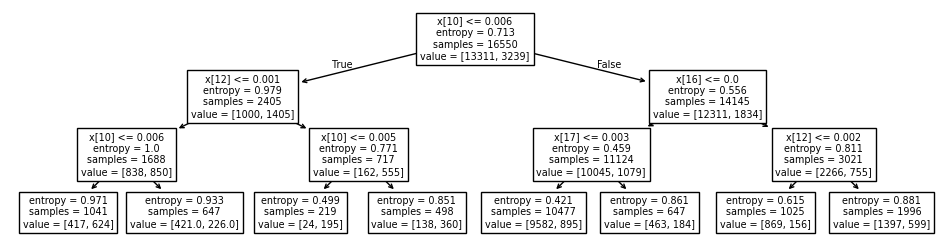

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,3))
tree.plot_tree(clf_gini_fit )

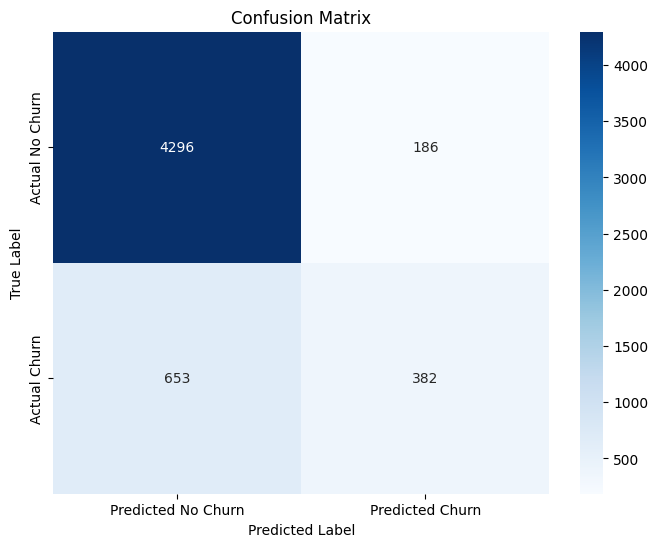

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4482
           1       0.41      0.46      0.43      1035

    accuracy                           0.78      5517
   macro avg       0.64      0.65      0.65      5517
weighted avg       0.79      0.78      0.78      5517

